In [12]:
import pandas as pd
import ast 

# Calssificazione del testo con una rete neurale
Dataset reperibile su [kaggle](https://www.kaggle.com/datasets)

In [13]:
datafile = "/Users/Flint/Data/recipes/it_recipes.csv"
df = pd.read_csv(datafile, index_col=0)
df = df.dropna()

In [14]:
df.head(2)

,Nome,Categoria,Link,Persone/Pezzi,Ingredienti,Steps
0,Tiramisù,Dolci,https://ricette.giallozafferano.it/Tiramisu.html,8,"[['Mascarpone', '750g'], ['Uova', '260g'], ['S...",Per preparare il tiramisù preparate il caffé c...
1,Cookies,Dolci,https://ricette.giallozafferano.it/Cookies.html,12,"[['Farina 00', '195g'], ['Burro', '100g'], ['B...","Per preparare i cookies, assicuratevi che il b..."


## Prepare training data

In [15]:
from nnet import create_text_dataloader

In [17]:
ingredients = []
for ilist in df.Ingredienti.values:
    lst = ast.literal_eval(ilist)
    ing = [x[0].lower() for x in lst]
    ingredients.append(ing)
labels = [x.lower() for x in df["Categoria"]]
for label in set(labels):
    print(label)

dolci
marmellate e conserve
piatti unici
torte salate
antipasti
primi piatti
contorni
salse e sughi
insalate
lievitati
secondi piatti
bevande


In [18]:
training_data = list(zip(ingredients, labels))
training_data[0]

(['mascarpone',
  'uova',
  'savoiardi',
  'zucchero',
  'caffè',
  'cacao amaro in polvere'],
 'dolci')

In [19]:
train_loader, feature_map, label_map, vocab_size, num_classes = create_text_dataloader(training_data, batch_size=4, shuffle=True)

DataLoader creato. VocabSize=1641, NumClassi=12


## Training

In [20]:
from nnet import TextClassifierHiddenLayer
import torch.nn as nn
import torch.optim as optim
import time

In [23]:
BATCH_SIZE = 4
HIDDEN_DIM = 6
LEARNING_RATE = 0.05
NUM_EPOCHS = 150
train_loader, feature_map, label_map, vocab_size, num_classes = create_text_dataloader(training_data, batch_size=4, shuffle=True)
print(f"Vocabolario: {vocab_size}")
print(f"Etichette: {num_classes}")

DataLoader creato. VocabSize=1641, NumClassi=12
Vocabolario: 1641
Etichette: 12


In [22]:
model = TextClassifierHiddenLayer(
    vocab_size=vocab_size, 
    hidden_dim=HIDDEN_DIM, 
    num_classes=num_classes
)
criterion = nn.NLLLoss()
optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)

In [11]:
print("\n--- STARTING TRAINING (Hidden Layer Model) ---")
start_time = time.time()
loss_history = []

for epoch in range(NUM_EPOCHS):
    
    epoch_running_loss = 0.0
    
    for features_batch, labels_batch in train_loader:
        
        # Set model to training mode
        model.train()
        
        # 1. Zero gradients
        optimizer.zero_grad()
        
        # 2. Forward pass
        log_probs = model(features_batch)
        
        # 3. Calculate loss
        # We use .squeeze() on labels just in case (to prevent 1D/2D errors)
        loss = criterion(log_probs, labels_batch.squeeze())
        
        # 4. Backward pass (calculate gradients)
        loss.backward()
        
        # 5. Update weights
        optimizer.step()
        
        epoch_running_loss += loss.item()
        
    # --- Logging per epoch ---
    avg_epoch_loss = epoch_running_loss / len(train_loader)
    loss_history.append(avg_epoch_loss)
    
    if (epoch + 1) % 10 == 0 or epoch == 0 or epoch == NUM_EPOCHS - 1:
        print(f"Epoch [{epoch+1: >3}/{NUM_EPOCHS}], Loss: {avg_epoch_loss:.6f}")

end_time = time.time()
print("--- TRAINING COMPLETE ---")
print(f"Completed in {end_time - start_time:.2f} seconds.")
print(f"Final Loss: {loss_history[-1]:.6f}")


--- STARTING TRAINING (Hidden Layer Model) ---
Epoch [  1/150], Loss: 1.325454
Epoch [ 10/150], Loss: 0.555556
Epoch [ 20/150], Loss: 0.393244
Epoch [ 30/150], Loss: 0.320481
Epoch [ 40/150], Loss: 0.280555
Epoch [ 50/150], Loss: 0.249875
Epoch [ 60/150], Loss: 0.231125
Epoch [ 70/150], Loss: 0.205602
Epoch [ 80/150], Loss: 0.199003
Epoch [ 90/150], Loss: 0.184019
Epoch [100/150], Loss: 0.172685
Epoch [110/150], Loss: 0.160011
Epoch [120/150], Loss: 0.155376
Epoch [130/150], Loss: 0.142142
Epoch [140/150], Loss: 0.135055
Epoch [150/150], Loss: 0.135382
--- TRAINING COMPLETE ---
Completed in 31.43 seconds.
Final Loss: 0.135382


In [29]:
import numpy as np

In [33]:
test_loader, feature_map, label_map, vocab_size, num_classes = create_text_dataloader(training_data, batch_size=1, shuffle=True)
y_true = []
y_pred = []
rev_label_map = dict([(v, k) for k, v in label_map.items()])
for features_batch, labels_batch in test_loader:
    expected_class = rev_label_map[labels_batch.detach().numpy()[0]]
    prediction = model(features_batch)
    predicted_label = rev_label_map[np.argmax(prediction.detach().numpy()[0])]
    y_true.append(expected_class)
    y_pred.append(predicted_label)

DataLoader creato. VocabSize=1641, NumClassi=12


In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

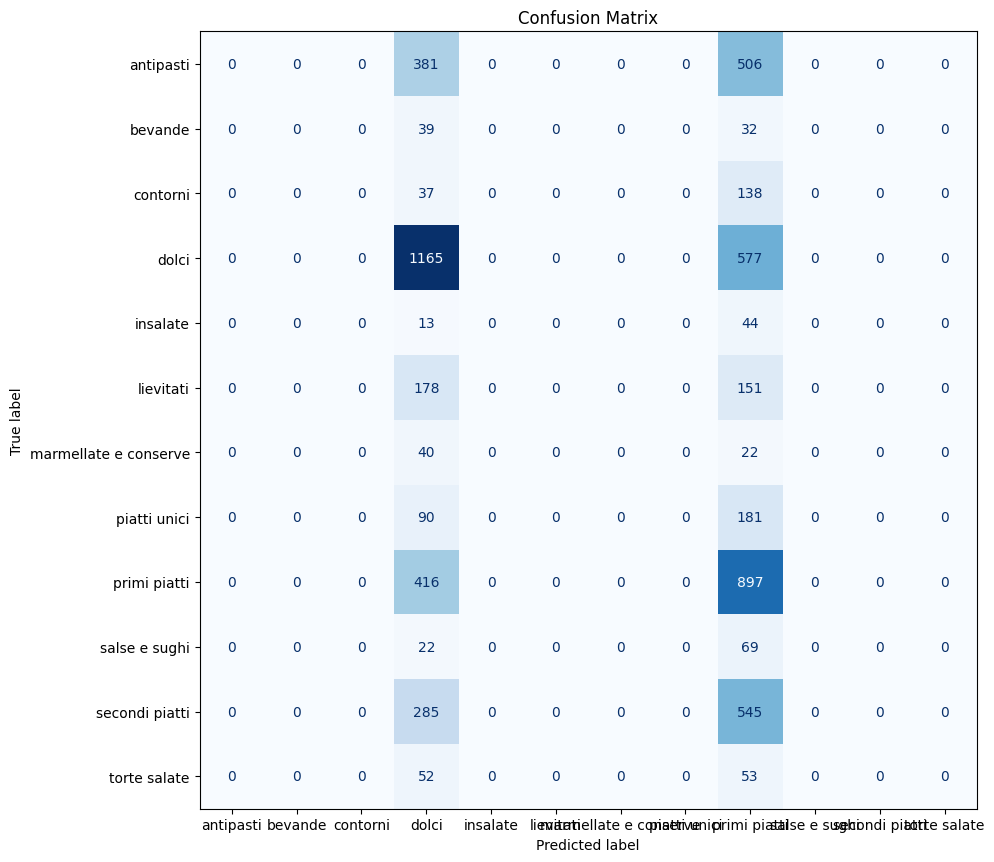

In [37]:
fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay.from_predictions(
    y_true=y_true, y_pred=y_pred,
#    display_labels=display_labels,
    cmap=plt.cm.Blues, normalize=None, ax=ax,
    colorbar=False
)
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

## Embedding

In [38]:
from nnet import get_token_to_hidden_weights

In [41]:
feature_list, vectors = [], []
for token, id in feature_map.items():
    vector = get_token_to_hidden_weights(model=model, token_name=token, feature_map=feature_map)
    feature_list.append(token)
    vectors.append(vector)
V = pd.DataFrame(np.array(vectors), index=feature_list)

In [42]:
V.head()

,0,1,2,3,4,5
abbacchio,-0.008861,0.018360,0.005357,0.022930,0.012116,-0.020610
acai in polvere,0.023810,0.014954,0.012740,-0.016533,-0.007951,-0.005828
acciughe (alici),0.001758,0.006696,0.001783,0.015945,-0.021554,0.003277
acciughe sott'olio,-0.017499,0.006520,-0.007646,-0.001876,0.018603,0.017135
acciughe sotto sale,-0.015450,-0.000244,-0.013542,0.021069,-0.015619,-0.011726


In [43]:
from sklearn.metrics.pairwise import cosine_similarity

In [44]:
S = pd.DataFrame(cosine_similarity(V, V), index=feature_list, columns=feature_list)
S.head()

/Users/Flint/.pyenv/versions/nlp/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/Flint/.pyenv/versions/nlp/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/Flint/.pyenv/versions/nlp/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,abbacchio,acai in polvere,acciughe (alici),acciughe sott'olio,acciughe sotto sale,aceto,aceto balsamico,aceto di lamponi,aceto di mele,aceto di riso,...,zucchero di canna a velo,zucchero grezzo di canna,zucchero integrale di canna,zucchero muscovado,zucchine,zucchine baby,zucchine bianche,zucchine gialle,zucchine tonde,zucchine trombetta
abbacchio,1.000000,-0.156477,0.140229,0.049553,0.429343,-0.374571,-0.865511,0.772802,-0.158407,0.378038,...,-0.051361,0.100982,0.197091,0.483804,-0.417364,0.008406,-0.285072,0.125126,-0.426090,0.409904
acai in polvere,-0.156477,1.000000,0.052499,-0.537170,-0.544676,0.522041,0.002727,-0.381641,0.596977,-0.077713,...,0.757839,-0.105051,-0.265926,-0.158354,-0.303035,-0.391807,0.404718,0.109223,0.354711,0.095217
acciughe (alici),0.140229,0.052499,1.000000,-0.414644,0.588971,-0.435960,0.114559,-0.294695,-0.492810,-0.360249,...,-0.026120,0.820746,0.650643,0.857995,0.399476,-0.431368,0.600732,0.356372,0.162289,-0.178882
acciughe sott'olio,0.049553,-0.537170,-0.414644,1.000000,-0.138636,-0.464761,-0.099213,0.381721,0.072283,-0.070964,...,-0.857214,0.141955,-0.513035,-0.126648,0.363173,0.069015,-0.170005,-0.792558,-0.404159,0.241397
acciughe sotto sale,0.429343,-0.544676,0.588971,-0.138636,1.000000,-0.499524,-0.259589,0.142389,-0.625824,-0.042315,...,-0.304067,0.451557,0.597955,0.557204,0.235020,-0.184350,0.076497,0.197308,0.088321,-0.373277


In [46]:
S.loc['acciughe (alici)'].sort_values(ascending=False).head(10)

acciughe (alici)         1.000000
frutto della passione    0.925371
brodo di pesce           0.915408
olive di gaeta           0.902377
pepe verde in grani      0.885113
macarons                 0.880282
farina di avena          0.871198
soppressata              0.858339
zucchero muscovado       0.857995
radiatori                0.855488
Name: acciughe (alici), dtype: float32